## Member Contributions

- **Saumya Aryan**  
  - Formalization of shot noise and Explanation of the Standard Quantum Limit (SQL)  
  - Motivation for the need of squeezing  

- **Sachin Raj**  
  - Detailed explanation of the LIGO interferometer components  
  - Formalism of gravitational waves  

- **Shrutija Swain**  
  - Study of experimental implementation of squeezing
  - description of various parts involved

- **P. Bhargavi**  
  - Quantum mechanical analysis of optical losses  
  - Phase loss in squeezing  

- **Swayam Saroj Patel**  
  - Reproducing and generating plots from the paper  
  - Modeling of various noise sources based on referenced literature  

#Enhanced Sensitivity of the LIGO Detector Using Squeezed States of Light
---
###Broadband Strain Sensitivity and Quantum Noise Theory

The sensitivity of these detectors is fundamentally limited by the quantum nature of light, which enters the interferometer's dark port as vacuum fluctuations.

At high frequencies, the dominant noise source is photon shot noise, which arises from the statistical fluctuations in the arrival time of photons at the output photodetector.

The amplitude spectral density of the ideal shot noise $\tilde{h}_{shot}(f)$ rises at higher frequencies due to the finite storage time ($\tau_s$) of the Fabry-Perot arm cavities(link to paper: https://arxiv.org/abs/0711.3041):

$$\tilde{h}_{shot}(f) \propto \sqrt{1+(4\pi f\tau_{s})^{2}}$$

To surpass this limit without simply increasing the laser power (which would worsen low-frequency radiation pressure noise), the 2013 LIGO experiment injected a squeezed vacuum state into the dark port. Squeezing reduces the uncertainty in the in-phase quadrature (which governs shot noise) at the mandatory expense of the orthogonal quadrature.

The Mathematics of Squeezing Degradation

While the Optical Parametric Oscillator (OPO) generated 10.3 dB of pure squeezing, environmental interactions degrade this quantum state before it is measured. We can derive the final measurable variance $V_{meas}$ step-by-step following the exact nomenclature of the 2013 experiment.

First, let the pure quantum states generated by the OPO be defined by their squeezed ($V_{-}$) and anti-squeezed ($V_{+}$) variances.

1. Optical Losses ($\eta$): The experiment experienced 56% optical loss (giving a detection efficiency of $\eta = 0.44$). This optical loss acts as an open port, allowing standard, uncorrelated vacuum fluctuations (normalized to a variance of 1) to leak back into the beam. The degraded normalized variances $V'_{\pm}$ are given by:

$$V'_{\pm} = \eta V_{\pm} + (1 - \eta)$$

2. Phase Noise ($\tilde{\theta}$): A residual phase noise of 37 mrad causes the highly noisy, anti-squeezed quadrature to project slightly into the measurement axis. Assuming the phase noise has a normal distribution with a standard deviation of $\tilde{\theta}$, the final detected squeezing quadrature $V_{meas}$ (which is $V_{-}^{\prime\prime}$) is obtained through the rotation equation:

$$V_{meas} = V_{-}^{\prime\prime} = V_{-}^{\prime} \cos^2\tilde{\theta} + V_{+}^{\prime} \sin^2\tilde{\theta}$$

3. Amplitude Sensitivity: Because gravitational wave detectors measure the amplitude of the radiation ($1/\sqrt{\mathrm{Hz}}$) rather than power, the actual improvement in the strain sensitivity is the square root of the power reduction (link to paper : https://www.nature.com/articles/nphoton.2013.177):

$$\text{Sensitivity Improvement} = \frac{1}{\sqrt{V_{meas}}}$$

The total detector noise $h_{total}(f)$ is the root-sum-square of this quantum noise and the classical technical noise $h_{tech}(f)$ (like seismic and thermal noise), which dominates at lower frequencies:

$$h_{total}(f) = \sqrt{ h_{shot}(f)^2 + h_{tech}(f)^2 }$$

In the following cell, we mathematically model the 56% optical losses ($\eta = 0.44$) and 37 mrad phase noise from the 2013 H1 experiment to show how the 10.3 dB of raw squeezing is degraded to the 2.15 dB broadband improvement observed in Figure 2 of the paper (link to the paper: https://www.nature.com/articles/nphoton.2013.177).

Generated Squeezing: 10.3 dB
Calculated Measurable Improvement: 2.16 dB


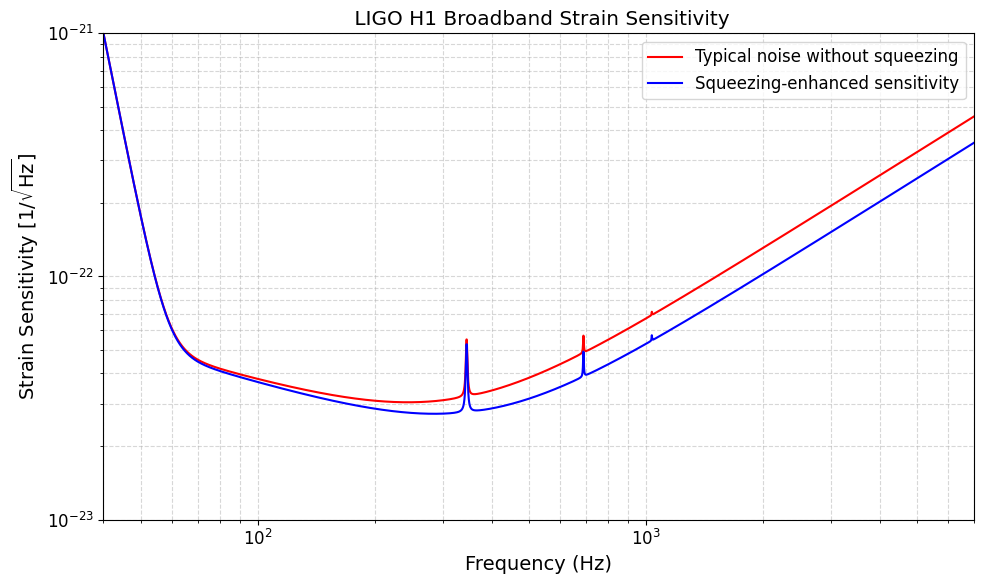

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# plot styling
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14})

# Squeezing Degradation Math
generated_squeezing_db = 10.3 # Raw squeezing generated by the OPO
V_sqz = 10 ** (-generated_squeezing_db / 10) # Squeezed variance
V_anti = 1 / V_sqz # Anti-squeezed variance

optical_loss = 0.56
eta = 1 - optical_loss # Detection efficiency

# Phase noise
phase_noise_mrad = 37
theta = phase_noise_mrad / 1000.0 # Convert to radians

# Degradation from optical losses
V_sqz_prime = eta * V_sqz + (1 - eta)
V_anti_prime = eta * V_anti + (1 - eta)

# Degradation from phase noise projection
V_meas = V_sqz_prime * (np.cos(theta)**2) + V_anti_prime * (np.sin(theta)**2)

# Calculate the amplitude sensitivity improvement
sensitivity_improvement = 1 / np.sqrt(V_meas)
improvement_db = 20 * np.log10(sensitivity_improvement)

print(f"Generated Squeezing: {generated_squeezing_db} dB")
print(f"Calculated Measurable Improvement: {improvement_db:.2f} dB")


# Phenomenological Noise Model
# Create a logarithmic frequency array from 40 Hz to 7000 Hz
freq = np.logspace(np.log10(40), np.log10(7000), 5000)

# A. Model the Shot Noise
# It rises at high frequencies due to the cavity storage time
h_shot = 1.3e-23 * np.sqrt(1 + (freq / 200.0)**2)

# B. Model the Technical Noise (Classical Noise)
# Seismic noise dominates below 50 Hz, Thermal noise dominates the mid-band
h_seismic = 1e-21 * (40.0 / freq)**8
h_thermal = 3.5e-23 * (100.0 / freq)**0.5
h_tech = np.sqrt(h_seismic**2 + h_thermal**2)

# Add standard mechanical resonance lines (Violin modes of the suspensions)
def add_resonance(f_array, center, width, amplitude):
    return amplitude / (1 + ((f_array - center) / width)**2)

h_tech += add_resonance(freq, 345, 2, 3e-23)
h_tech += add_resonance(freq, 690, 2, 2e-23)
h_tech += add_resonance(freq, 1035, 2, 1e-23)

# C. Calculate the Total Strain Sensitivity
# Baseline noise without squeezing
total_noise_baseline = np.sqrt(h_shot**2 + h_tech**2)

# Apply the squeezing reduction factor strictly to the shot noise component
h_shot_squeezed = h_shot / sensitivity_improvement
total_noise_squeezed = np.sqrt(h_shot_squeezed**2 + h_tech**2)

plt.figure(figsize=(10, 6))

plt.loglog(freq, total_noise_baseline, color='red', linewidth=1.5, label='Typical noise without squeezing')
plt.loglog(freq, total_noise_squeezed, color='blue', linewidth=1.5, label='Squeezing-enhanced sensitivity')

plt.xlim(40, 7000)
plt.ylim(1e-23, 1e-21)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Strain Sensitivity [$1/\sqrt{\mathrm{Hz}}$]')
plt.title(' LIGO H1 Broadband Strain Sensitivity')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

####The Technical Noise Bottleneck


While the above figure shows a massive broadband improvement, the enhancement is not uniform. If we zoom into the mid-frequency region (100 Hz to 500 Hz), we can see exactly how classical noise limits the quantum enhancement.

Squeezing strictly reduces quantum shot noise. It has no effect on classical technical noise sources. In this frequency band, the inferred technical noise (the black curve) is dominated by:

- Low-Frequency Continuum: A combination of seismic motion, Newtonian gravity gradient noise, and thermal noise that rises steeply below 150 Hz.

- Narrow Line Features: Sharp spikes in the noise caused by 60 Hz AC power line harmonics, and the violin modes (mechanical resonances of the fused silica fibers suspending the test masses) at approximately 345 Hz.

Because these technical noises dominate the shot noise at lower frequencies, the squeezing-enhanced sensitivity curve is forced to merge with the baseline technical noise floor.

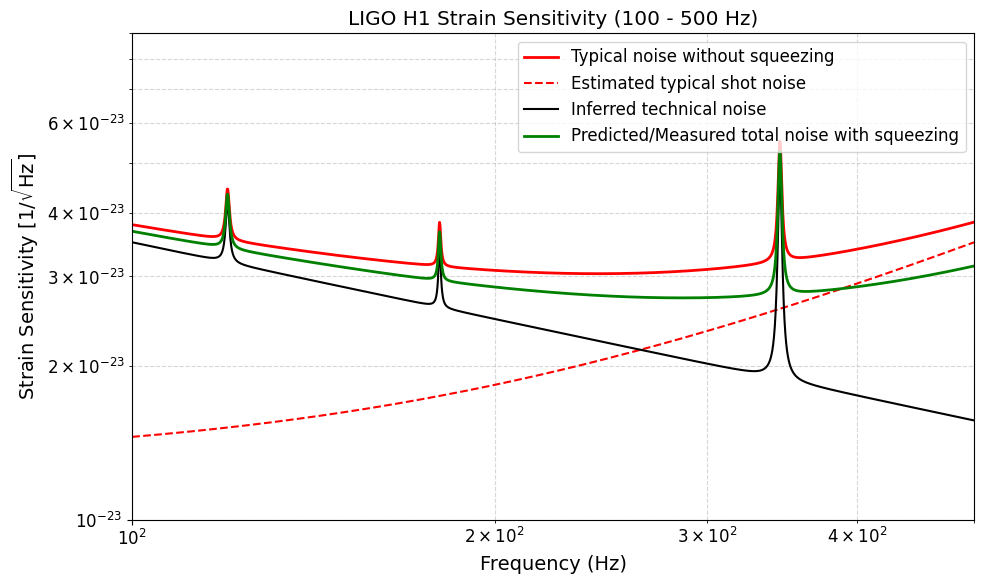

In [ ]:
# Zoomed Mid-Frequency Model

# Create a frequency array from 100 Hz to 500 Hz
freq_zoom = np.logspace(np.log10(100), np.log10(500), 2000)

# Re-calculate the shot noise for this specific zoomed array
shot_noise_zoom = 1.3e-23 * np.sqrt(1 + (freq_zoom / 200.0)**2)

# Build the Inferred Technical Noise (Black Curve)
# Using the same f^-8 seismic and f^-0.5 thermal slopes as before
seismic_zoom = 1e-21 * (40.0 / freq_zoom)**8
thermal_zoom = 3.5e-23 * (100.0 / freq_zoom)**0.5
tech_noise_zoom = np.sqrt(seismic_zoom**2 + thermal_zoom**2)

# Add the specific narrow line features seen in this band
# 1. AC Power Harmonics (e.g., 120 Hz, 180 Hz)
tech_noise_zoom += add_resonance(freq_zoom, 120, 0.5, 1e-23)
tech_noise_zoom += add_resonance(freq_zoom, 180, 0.5, 8e-24)
# 2. Suspension Violin Mode (approx 345 Hz)
tech_noise_zoom += add_resonance(freq_zoom, 345, 1.5, 3e-23)

# Calculate the totals
total_noise_no_sqz_zoom = np.sqrt(shot_noise_zoom**2 + tech_noise_zoom**2)

# Apply the 2.15 dB squeezing reduction ONLY to the shot noise
squeezed_shot_zoom = shot_noise_zoom / sensitivity_improvement
total_noise_with_sqz_zoom = np.sqrt(squeezed_shot_zoom**2 + tech_noise_zoom**2)

plt.figure(figsize=(10, 6))

plt.loglog(freq_zoom, total_noise_no_sqz_zoom, color='red', linewidth=2, label='Typical noise without squeezing')
plt.loglog(freq_zoom, shot_noise_zoom, color='red', linestyle='--', label='Estimated typical shot noise')
plt.loglog(freq_zoom, tech_noise_zoom, color='black', label='Inferred technical noise')
plt.loglog(freq_zoom, total_noise_with_sqz_zoom, color='green', linewidth=2, label='Predicted/Measured total noise with squeezing')

plt.xlim(100, 500)
plt.ylim(1e-23, 9e-23)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Strain Sensitivity [$1/\sqrt{\mathrm{Hz}}$]')
plt.title('LIGO H1 Strain Sensitivity (100 - 500 Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

####Squeezing Enhancement Ratio

To clearly visualize the frequency dependence of the quantum enhancement, we can plot the ratio of the baseline sensitivity to the squeezing-enhanced sensitivity.

If the LIGO detector was completely limited by quantum shot noise at all frequencies, this ratio would be a perfectly flat horizontal line at our calculated limit of 2.15 dB. However, because the inferred technical noise dominates the lower frequencies, the actual improvement drops toward 0 dB as we approach 100 Hz.

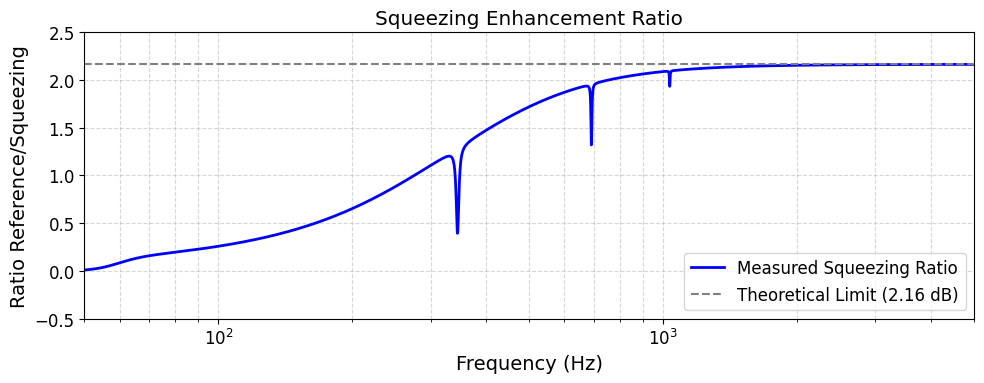

In [ ]:
# We use the broadband arrays calculated in Cell 2 to find the ratio across the whole spectrum
ratio_linear = total_noise_baseline / total_noise_squeezed

# Convert the ratio to Decibels (dB)
ratio_db = 20 * np.log10(ratio_linear)

plt.figure(figsize=(10, 4))

# Plot the calculated ratio
plt.semilogx(freq, ratio_db, color='blue', linewidth=2, label='Measured Squeezing Ratio')

# Plot the theoretical flat limit if shot noise was the only noise source
plt.axhline(improvement_db, color='gray', linestyle='--', label=f'Theoretical Limit ({improvement_db:.2f} dB)')

plt.xlim(50, 5000)
plt.ylim(-0.5, 2.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio Reference/Squeezing')
plt.title('Squeezing Enhancement Ratio')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

####The Future: Advanced LIGO and Frequency-Dependent Squeezing

As we move into the era of Advanced LIGO, standard (frequency-independent) squeezed light decreases phase uncertainty (lowering high-frequency shot noise), but Heisenberg uncertainty principle demands that we increase amplitude uncertainty, amplifying low-frequency radiation pressure noise. To improve sensitivity across the entire spectrum, Advanced LIGO requires frequency-dependent squeezing.

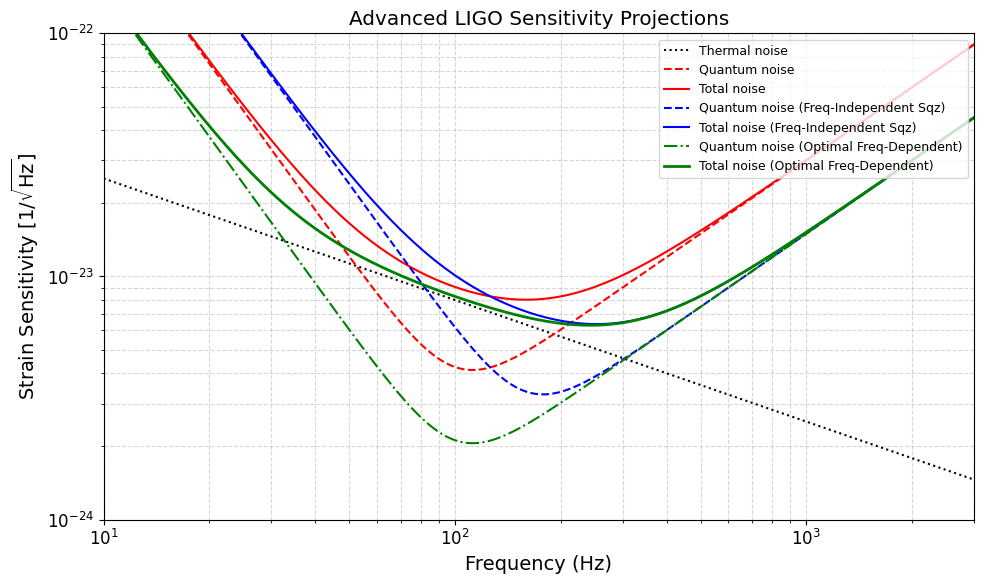

In [ ]:
freq_adv = np.logspace(1, 3.5, 2000) # 10 Hz to ~3000 Hz

# Thermal Noise (Dominates the mid-band)
adv_thermal = 8e-24 * (100.0 / freq_adv)**0.5

# Quantum Noise (Shot Noise + Radiation Pressure Noise)
# Shot noise scales as f, Radiation Pressure scales as 1/f^2
adv_shot = 3e-24 * (freq_adv / 100.0)
adv_rad_pressure = 3e-24 * (100.0 / freq_adv)**2
adv_quantum_base = np.sqrt(adv_shot**2 + adv_rad_pressure**2)

adv_total_base = np.sqrt(adv_quantum_base**2 + adv_thermal**2)

# Frequency-Independent Squeezing (Like the 2013 experiment)
# Reduces shot noise by factor S, but AMPLIFIES radiation pressure by factor S
S_factor = 2.0 # Assume a factor of 2 amplitude improvement (approx 6 dB)
adv_shot_sqz = adv_shot / S_factor
adv_rad_pressure_antisqz = adv_rad_pressure * S_factor # The Anti-squeezing penalty!

adv_quantum_fi = np.sqrt(adv_shot_sqz**2 + adv_rad_pressure_antisqz**2)
adv_total_fi = np.sqrt(adv_quantum_fi**2 + adv_thermal**2)

# Optimal Frequency-Dependent Squeezing (Using a Filter Cavity)
# Reduces BOTH shot noise and radiation pressure noise
adv_quantum_fd = adv_quantum_base / S_factor
adv_total_fd = np.sqrt(adv_quantum_fd**2 + adv_thermal**2)

plt.figure(figsize=(10, 6))

plt.loglog(freq_adv, adv_thermal, color='black', linestyle=':', label='Thermal noise')
plt.loglog(freq_adv, adv_quantum_base, color='red', linestyle='--', label='Quantum noise')
plt.loglog(freq_adv, adv_total_base, color='red', label='Total noise')

# Frequency-Independent Squeezing (Note the low-frequency penalty)
plt.loglog(freq_adv, adv_quantum_fi, color='blue', linestyle='--', label='Quantum noise (Freq-Independent Sqz)')
plt.loglog(freq_adv, adv_total_fi, color='blue', label='Total noise (Freq-Independent Sqz)')

# Optimal Frequency-Dependent Squeezing
plt.loglog(freq_adv, adv_quantum_fd, color='green', linestyle='-.', label='Quantum noise (Optimal Freq-Dependent)')
plt.loglog(freq_adv, adv_total_fd, color='green', linewidth=2, label='Total noise (Optimal Freq-Dependent)')

plt.xlim(10, 3000)
plt.ylim(1e-24, 1e-22)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Strain Sensitivity [$1/\sqrt{\mathrm{Hz}}$]')
plt.title('Advanced LIGO Sensitivity Projections')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

####Professional Noise Budgets with pygwinc

Throughout this notebook, we have built phenomenological, analytical models from scratch using numpy and matplotlib to demonstrate the underlying physics. In professional LSC (LIGO Scientific Collaboration) research, a library called pygwinc (Python Gravitational Wave Interferometer Noise Calculator) can be utilized.

pygwinc processes complex YAML configuration files containing the physical parameters of the detector (e.g., precise mirror masses, laser wavelength, coating dielectric properties, and optical losses) to automatically compute and sum the quantum, thermal, and seismic noise curves.

Below is a minimal demonstration of how pygwinc is called in Python to generate an Advanced LIGO noise budget natively. (Note: This cell requires the gwinc package to be installed via pip install gwinc).

In [ ]:
!pip install gwinc

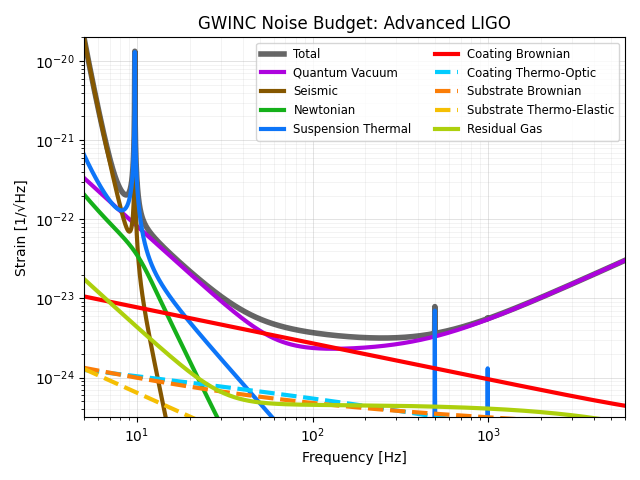

In [ ]:
# Tell the pygwinc command-line tool to calculate aLIGO and save the plot
!gwinc --save aLIGO_budget.png aLIGO

# Display the saved image directly in Colab
from IPython.display import Image
Image('aLIGO_budget.png')

A+ Upgrade Noise Budget:


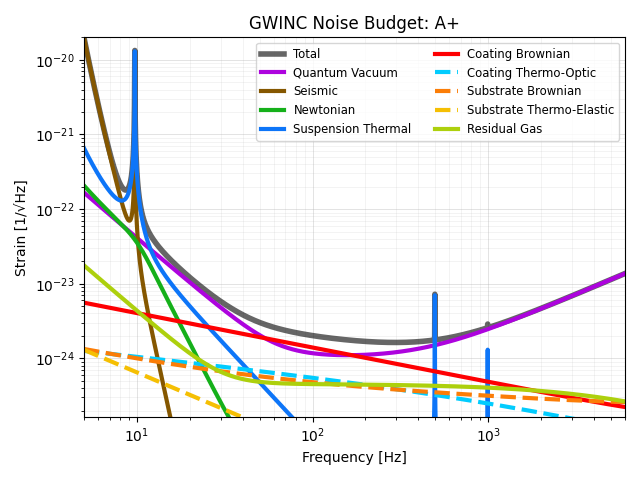

Cosmic Explorer (40km) Noise Budget:


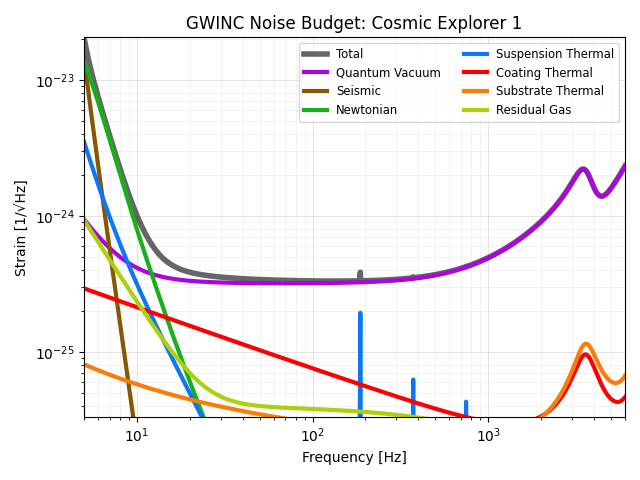

In [ ]:
# Generate the budget plot for the A+ Upgrade
!gwinc --save Aplus_budget.png Aplus
print("A+ Upgrade Noise Budget:")
display(Image('Aplus_budget.png'))

# Generate the budget plot for the Cosmic Explorer (Phase 1)
!gwinc --save CE1_budget.png CE1
print("Cosmic Explorer (40km) Noise Budget:")
display(Image('CE1_budget.png'))